# 🤖 Fine-tuning BETO para Detección de Bullying - Fase 8

---

## 🎯 OBJETIVO

Fine-tuning del modelo **BETO** (BERT en español) para clasificación binaria de texto ofensivo/bullying.

---

## 📊 MODELO BASE

**BETO:** `dccuchile/bert-base-spanish-wwm-cased`
- BERT preentrenado en español
- 110 millones de parámetros
- Whole Word Masking (WWM)
- Case-sensitive (distingue mayúsculas/minúsculas)

**Por qué BETO:**
- ✅ Entiende **contexto** ("no eres tonto" ≠ "eres tonto")
- ✅ Captura **semántica** ("gilipollas" ≈ "idiota")
- ✅ Maneja **negaciones, sarcasmo, ironía**
- ✅ Preentrenado en español (vocabulario rico)

---

## 📋 DATASETS

| Conjunto | Ejemplos | Uso |
|----------|----------|-----|
| **Train** | 5,919 | Entrenamiento |
| **Validation** | 1,269 | Early stopping y ajuste |
| **Test** | 1,269 | Evaluación final |

**Balance:** ~50% clase 0 (no ofensivo), ~50% clase 1 (ofensivo)

---

## 🎯 MEJORA ESPERADA
Baseline SVM:        84.36% F1-Score (overfitting 13%)
Baseline LightGBM:   84.86% F1-Score (overfitting 1.97%)
BETO (esperado):     92-95% F1-Score

**Reducción de errores esperada:**
- Falsos Negativos: 104 → 30-50 (~70% reducción)
- Falsos Positivos: 91 → 40-60 (~50% reducción)

---

## ⚙️ CONFIGURACIÓN DE ENTRENAMIENTO

**Hardware:** Google Colab GPU (Tesla T4 - 16GB VRAM)

**Hiperparámetros:**
- Learning rate: 2e-5
- Batch size: 16
- Epochs: 3-4
- Max length: 128 tokens
- Warmup steps: 500
- Weight decay: 0.01


---

## 📁 ESTRUCTURA

1. Verificar GPU
2. Instalar dependencias
3. Cargar datos
4. Tokenización
5. Crear datasets
6. Configurar Trainer
7. Entrenar modelo
8. Evaluar en test
9. Guardar modelo
10. Comparar con baselines

---

In [1]:
import torch
import sys

print("="*70)
print("VERIFICACIÓN DEL ENTORNO")
print("="*70)

# Verificar GPU
print(f"\nGPU disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU nombre: {torch.cuda.get_device_name(0)}")
    print(f"GPU memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA version: {torch.version.cuda}")
    print("\n GPU configurada correctamente")
else:
    print("\n WARNING: GPU no disponible")
    print("   Ve a: Runtime → Change runtime type → Hardware accelerator → GPU")
    print("   Luego reinicia el notebook")

# Verificar versiones
print(f"\nPython version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")

print("\n" + "="*70)

VERIFICACIÓN DEL ENTORNO

GPU disponible: True
GPU nombre: Tesla T4
GPU memoria total: 15.64 GB
CUDA version: 12.8

✅ GPU configurada correctamente

Python version: 3.12.13
PyTorch version: 2.10.0+cu128



In [2]:
print("="*70)
print("INSTALANDO DEPENDENCIAS")
print("="*70)

# Instalar librerías necesarias
!pip install -q transformers datasets evaluate accelerate

print("\n✅ Dependencias instaladas")

# Verificar versiones
import transformers
import datasets
import evaluate

print(f"\nTransformers version: {transformers.__version__}")
print(f"Datasets version: {datasets.__version__}")
print(f"Evaluate version: {evaluate.__version__}")

print("\n" + "="*70)

INSTALANDO DEPENDENCIAS
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00

✅ Dependencias instaladas

Transformers version: 5.0.0
Datasets version: 4.0.0
Evaluate version: 0.4.6



In [3]:
print("="*70)
print("IMPORTANDO LIBRERÍAS")
print("="*70)

# Imports estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Datasets
from datasets import Dataset, DatasetDict

# Evaluate
import evaluate

print("\n Todas las librerías importadas correctamente")
print("\n" + "="*70)

IMPORTANDO LIBRERÍAS

 Todas las librerías importadas correctamente



In [4]:
print("="*70)
print("SUBIR ARCHIVOS DESDE TU PC")
print("="*70)

from google.colab import files
import io

print("\n📁 Sube los 3 archivos CSV:")
print("   1. train.csv")
print("   2. val.csv")
print("   3. test.csv")
print("\nClick en 'Elegir archivos' y selecciona los 3 archivos")
print("-"*70)

# Subir archivos
uploaded = files.upload()

print("\n Archivos subidos:")
for filename in uploaded.keys():
    print(f"   - {filename} ({len(uploaded[filename])/1024:.1f} KB)")

print("\n" + "="*70)

SUBIR ARCHIVOS DESDE TU PC

📁 Sube los 3 archivos CSV:
   1. train.csv
   2. val.csv
   3. test.csv

Click en 'Elegir archivos' y selecciona los 3 archivos
----------------------------------------------------------------------


Saving test.csv to test.csv
Saving train.csv to train.csv
Saving val.csv to val.csv

 Archivos subidos:
   - test.csv (111.4 KB)
   - train.csv (524.1 KB)
   - val.csv (111.5 KB)



In [7]:
print("="*70)
print("CARGAR Y VERIFICAR DATOS")
print("="*70)

# Cargar CSVs
df_train = pd.read_csv('train.csv')
df_val = pd.read_csv('val.csv')
df_test = pd.read_csv('test.csv')

print("\n DATASETS CARGADOS:")
print("-"*70)

print(f"\nTrain: {len(df_train)} ejemplos")
print(f"   Clase 0: {(df_train['label']==0).sum()} ({(df_train['label']==0).sum()/len(df_train)*100:.1f}%)")
print(f"   Clase 1: {(df_train['label']==1).sum()} ({(df_train['label']==1).sum()/len(df_train)*100:.1f}%)")

print(f"\nValidation: {len(df_val)} ejemplos")
print(f"   Clase 0: {(df_val['label']==0).sum()} ({(df_val['label']==0).sum()/len(df_val)*100:.1f}%)")
print(f"   Clase 1: {(df_val['label']==1).sum()} ({(df_val['label']==1).sum()/len(df_val)*100:.1f}%)")

print(f"\nTest: {len(df_test)} ejemplos")
print(f"   Clase 0: {(df_test['label']==0).sum()} ({(df_test['label']==0).sum()/len(df_test)*100:.1f}%)")
print(f"   Clase 1: {(df_test['label']==1).sum()} ({(df_test['label']==1).sum()/len(df_test)*100:.1f}%)")

print("\n" + "-"*70)
print("PRIMEROS 3 EJEMPLOS DE TRAIN:")
print("-"*70)
print(df_train.head(3))

print("\n Datos cargados correctamente")
print("="*70)

CARGAR Y VERIFICAR DATOS

 DATASETS CARGADOS:
----------------------------------------------------------------------

Train: 5919 ejemplos
   Clase 0: 2982 (50.4%)
   Clase 1: 2937 (49.6%)

Validation: 1269 ejemplos
   Clase 0: 639 (50.4%)
   Clase 1: 630 (49.6%)

Test: 1269 ejemplos
   Clase 0: 639 (50.4%)
   Clase 1: 630 (49.6%)

----------------------------------------------------------------------
PRIMEROS 3 EJEMPLOS DE TRAIN:
----------------------------------------------------------------------
                                               texto  label
0  Con esa actitud es normal que nadie te quiera,...      1
1  No me roban en VILLA LUGANO saliendo de estudi...      1
2  Tienes una imagen penosa, búscate un hobby, to...      1

 Datos cargados correctamente


In [8]:
print("="*70)
print("CARGAR TOKENIZER DE BETO")
print("="*70)

# Cargar tokenizer del modelo BETO
model_name = "dccuchile/bert-base-spanish-wwm-cased"

print(f"\nCargando tokenizer de: {model_name}")
print("(Esto puede tardar 10-20 segundos...)")

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("\n✅ Tokenizer cargado correctamente")

print("\n" + "-"*70)
print("EJEMPLO DE TOKENIZACIÓN:")
print("-"*70)

# Ejemplo
texto_ejemplo = "eres un gilipollas"
tokens = tokenizer.tokenize(texto_ejemplo)
token_ids = tokenizer.encode(texto_ejemplo)

print(f"\nTexto original: '{texto_ejemplo}'")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

# Otro ejemplo
texto_ejemplo2 = "no eres tonto"
tokens2 = tokenizer.tokenize(texto_ejemplo2)

print(f"\nTexto original: '{texto_ejemplo2}'")
print(f"Tokens: {tokens2}")

print("\n" + "="*70)

CARGAR TOKENIZER DE BETO

Cargando tokenizer de: dccuchile/bert-base-spanish-wwm-cased
(Esto puede tardar 10-20 segundos...)


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]


✅ Tokenizer cargado correctamente

----------------------------------------------------------------------
EJEMPLO DE TOKENIZACIÓN:
----------------------------------------------------------------------

Texto original: 'eres un gilipollas'
Tokens: ['eres', 'un', 'gilipollas']
Token IDs: [4, 2149, 1049, 22688, 5]

Texto original: 'no eres tonto'
Tokens: ['no', 'eres', 'tonto']



In [9]:
print("="*70)
print("TOKENIZAR TODOS LOS DATASETS")
print("="*70)

# Función de tokenización
def tokenize_function(examples):
    """
    Tokeniza una lista de textos.

    Args:
        examples: dict con clave 'texto' conteniendo lista de textos

    Returns:
        dict con tokens (input_ids, attention_mask)
    """
    return tokenizer(
        examples['texto'],
        padding='max_length',    # Rellenar hasta max_length
        truncation=True,         # Cortar si es más largo
        max_length=128           # Longitud máxima (tokens)
    )

print("\nParámetros de tokenización:")
print("   - max_length: 128 tokens")
print("   - padding: Rellenar textos cortos hasta 128")
print("   - truncation: Cortar textos largos a 128")

# Convertir DataFrames a Datasets de Hugging Face
print("\nConvirtiendo DataFrames a Datasets...")

train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)
test_dataset = Dataset.from_pandas(df_test)

print(" Datasets creados")

# Tokenizar
print("\nTokenizando datasets (esto tarda ~30 segundos)...")

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print(" Tokenización completada")

# Preparar datasets para el modelo
print("\nPreparando formato para BETO...")

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(" Formato preparado")

print("\n" + "="*70)
print("RESUMEN DE DATASETS TOKENIZADOS:")
print("="*70)

print(f"\nTrain: {len(train_dataset)} ejemplos")
print(f"Validation: {len(val_dataset)} ejemplos")
print(f"Test: {len(test_dataset)} ejemplos")

print("\nColumnas del dataset:")
print(f"   {train_dataset.column_names}")

print("\nEjemplo de 1 muestra tokenizada:")
print("-"*70)
print(f"input_ids shape: {train_dataset[0]['input_ids'].shape}")
print(f"attention_mask shape: {train_dataset[0]['attention_mask'].shape}")
print(f"label: {train_dataset[0]['labels']}")

print("\n Datos listos para entrenar BETO")
print("="*70)

TOKENIZAR TODOS LOS DATASETS

Parámetros de tokenización:
   - max_length: 128 tokens
   - padding: Rellenar textos cortos hasta 128
   - truncation: Cortar textos largos a 128

Convirtiendo DataFrames a Datasets...
 Datasets creados

Tokenizando datasets (esto tarda ~30 segundos)...


Map:   0%|          | 0/5919 [00:00<?, ? examples/s]

Map:   0%|          | 0/1269 [00:00<?, ? examples/s]

Map:   0%|          | 0/1269 [00:00<?, ? examples/s]

 Tokenización completada

Preparando formato para BETO...
 Formato preparado

RESUMEN DE DATASETS TOKENIZADOS:

Train: 5919 ejemplos
Validation: 1269 ejemplos
Test: 1269 ejemplos

Columnas del dataset:
   ['texto', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']

Ejemplo de 1 muestra tokenizada:
----------------------------------------------------------------------
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: 1

 Datos listos para entrenar BETO


In [10]:
print("="*70)
print("CARGAR MODELO BETO")
print("="*70)

# Cargar modelo BETO preentrenado para clasificación
print(f"\nCargando modelo: {model_name}")
print("(Esto puede tardar 20-30 segundos...)")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,           # 2 clases: 0 (no ofensivo), 1 (ofensivo)
    id2label={0: "No ofensivo", 1: "Ofensivo"},
    label2id={"No ofensivo": 0, "Ofensivo": 1}
)

print("\n Modelo BETO cargado correctamente")

# Mover modelo a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"\nModelo movido a: {device}")

# Información del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "-"*70)
print("INFORMACIÓN DEL MODELO:")
print("-"*70)
print(f"Total de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Tamaño aproximado: {total_params * 4 / (1024**2):.2f} MB")

print("\n" + "="*70)

CARGAR MODELO BETO

Cargando modelo: dccuchile/bert-base-spanish-wwm-cased
(Esto puede tardar 20-30 segundos...)


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 


 Modelo BETO cargado correctamente


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Modelo movido a: cuda

----------------------------------------------------------------------
INFORMACIÓN DEL MODELO:
----------------------------------------------------------------------
Total de parámetros: 109,852,418
Parámetros entrenables: 109,852,418
Tamaño aproximado: 419.05 MB



In [11]:
print("="*70)
print("CONFIGURAR MÉTRICAS DE EVALUACIÓN")
print("="*70)

# Cargar métricas
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

print("\n Métricas cargadas:")
print("   - Accuracy")
print("   - Precision")
print("   - Recall")
print("   - F1-Score")

# Definir función para calcular métricas
def compute_metrics(eval_pred):
    """
    Calcula métricas durante la evaluación.

    Args:
        eval_pred: tupla (predictions, labels)

    Returns:
        dict con accuracy, precision, recall, f1
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels, average='binary')
    recall = recall_metric.compute(predictions=predictions, references=labels, average='binary')
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='binary')

    return {
        'accuracy': accuracy['accuracy'],
        'precision': precision['precision'],
        'recall': recall['recall'],
        'f1': f1['f1']
    }

print("\n Función compute_metrics definida")
print("\n" + "="*70)

CONFIGURAR MÉTRICAS DE EVALUACIÓN



 Métricas cargadas:
   - Accuracy
   - Precision
   - Recall
   - F1-Score

 Función compute_metrics definida



In [18]:
print("="*70)
print("CONFIGURAR PARÁMETROS DE ENTRENAMIENTO")
print("="*70)

# Definir argumentos de entrenamiento
training_args = TrainingArguments(
    output_dir="./beto-bullying",              # Carpeta para guardar checkpoints
    eval_strategy="epoch",                     # Evaluar cada epoch (CAMBIADO)
    save_strategy="epoch",                     # Guardar checkpoint cada epoch
    learning_rate=2e-5,                        # Tasa de aprendizaje
    per_device_train_batch_size=16,           # Batch size para entrenamiento
    per_device_eval_batch_size=16,            # Batch size para evaluación
    num_train_epochs=3,                        # Número de epochs
    weight_decay=0.01,                         # Regularización L2
    warmup_steps=500,                          # Pasos de calentamiento
    logging_dir='./logs',                      # Carpeta para logs
    logging_steps=100,                         # Log cada 100 pasos
    load_best_model_at_end=True,              # Cargar mejor modelo al final
    metric_for_best_model="f1",               # Usar F1 para elegir mejor modelo
    greater_is_better=True,                    # Mayor F1 = mejor
    save_total_limit=2,                        # Guardar solo 2 checkpoints
    report_to="none",                          # No reportar a wandb/tensorboard
    fp16=True                                  # Usar precisión mixta (más rápido en GPU)
)

print("\n✅ Parámetros de entrenamiento configurados:")
print("-"*70)
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Warmup steps: {training_args.warmup_steps}")
print(f"   Weight decay: {training_args.weight_decay}")
print(f"   Precisión mixta (fp16): {training_args.fp16}")
print(f"   Métrica para mejor modelo: {training_args.metric_for_best_model}")

print("\n" + "="*70)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


CONFIGURAR PARÁMETROS DE ENTRENAMIENTO

✅ Parámetros de entrenamiento configurados:
----------------------------------------------------------------------
   Learning rate: 2e-05
   Batch size: 16
   Epochs: 3
   Warmup steps: 500
   Weight decay: 0.01
   Precisión mixta (fp16): True
   Métrica para mejor modelo: f1



In [19]:
print("="*70)
print("CREAR TRAINER Y ENTRENAR BETO")
print("="*70)

# Crear Trainer
print("\nCreando Trainer...")

trainer = Trainer(
    model=model,                          # Modelo BETO
    args=training_args,                   # Configuración de entrenamiento
    train_dataset=train_dataset,         # Dataset de entrenamiento
    eval_dataset=val_dataset,            # Dataset de validación
    compute_metrics=compute_metrics,      # Función de métricas
)

print("✅ Trainer creado")

print("\n" + "="*70)
print("INICIANDO ENTRENAMIENTO")
print("="*70)

print("\n⏰ TIEMPO ESTIMADO: 20-30 minutos")
print("\n🚀 El entrenamiento comenzará ahora...")
print("   - Verás barras de progreso para cada epoch")
print("   - Al final de cada epoch verás las métricas")
print("   - NO cierres esta pestaña mientras entrena")
print("\n" + "-"*70)

# Entrenar modelo
trainer.train()

print("\n" + "="*70)
print(" ENTRENAMIENTO COMPLETADO")
print("="*70)

CREAR TRAINER Y ENTRENAR BETO

Creando Trainer...
✅ Trainer creado

INICIANDO ENTRENAMIENTO

⏰ TIEMPO ESTIMADO: 20-30 minutos

🚀 El entrenamiento comenzará ahora...
   - Verás barras de progreso para cada epoch
   - Al final de cada epoch verás las métricas
   - NO cierres esta pestaña mientras entrena

----------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.375359,0.373591,0.836879,0.971047,0.692063,0.808156
2,0.264626,0.311400,0.873128,0.919499,0.815873,0.864592
3,0.141774,0.480792,0.874704,0.903945,0.836508,0.868920


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 ENTRENAMIENTO COMPLETADO


In [20]:
print("="*70)
print("EVALUAR MODELO EN TEST")
print("="*70)

print("\n⚠️ Recordatorio: TEST nunca ha sido visto por el modelo")
print("   Es la evaluación REAL del rendimiento")

print("\nEvaluando en TEST...")

# Predecir en test
predictions = trainer.predict(test_dataset)

# Extraer predicciones y labels
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Calcular métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred)

print("\n" + "="*70)
print("RESULTADOS EN TEST")
print("="*70)

print(f"\nAccuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")

print("\n" + "="*70)
print("COMPARACIÓN: BASELINES vs BETO (todos en TEST)")
print("="*70)

# Métricas baselines en test
svm_f1 = 0.8436
lightgbm_f1 = 0.8486

print(f"\n{'Modelo':<15} {'F1-Score':>12} {'Mejora vs SVM':>15}")
print("-"*70)
print(f"{'SVM':<15} {svm_f1:>11.2%} {'-':>15}")
print(f"{'LightGBM':<15} {lightgbm_f1:>11.2%} {(lightgbm_f1-svm_f1)*100:>14.2f}%")
print(f"{'BETO':<15} {test_f1:>11.2%} {(test_f1-svm_f1)*100:>14.2f}%")

mejora_vs_lightgbm = (test_f1 - lightgbm_f1) * 100

print("\n" + "-"*70)
print("ANÁLISIS:")
print("-"*70)

if test_f1 >= 0.92:
    print(f"\n✅ EXCELENTE: BETO alcanzó el objetivo (92%+)")
    print(f"   F1-Score: {test_f1*100:.2f}%")
elif test_f1 >= 0.87:
    print(f"\n✅ BUENO: BETO mejoró sobre baselines")
    print(f"   F1-Score: {test_f1*100:.2f}%")
    print(f"   Mejora vs LightGBM: +{mejora_vs_lightgbm:.2f}%")
    if mejora_vs_lightgbm < 2:
        print(f"\n⚠️ Mejora modesta - Podríamos optimizar:")
        print(f"   - Entrenar más epochs (4-5)")
        print(f"   - Ajustar learning rate")
        print(f"   - Usar data augmentation")
else:
    print(f"\n⚠️ REGULAR: BETO no mejoró significativamente")
    print(f"   F1-Score: {test_f1*100:.2f}%")
    print(f"   Similar a baselines")

print("\n" + "="*70)

EVALUAR MODELO EN TEST

⚠️ Recordatorio: TEST nunca ha sido visto por el modelo
   Es la evaluación REAL del rendimiento

Evaluando en TEST...



RESULTADOS EN TEST

Accuracy:  0.8881 (88.81%)
Precision: 0.8961 (89.61%)
Recall:    0.8762 (87.62%)
F1-Score:  0.8860 (88.60%)

COMPARACIÓN: BASELINES vs BETO (todos en TEST)

Modelo              F1-Score   Mejora vs SVM
----------------------------------------------------------------------
SVM                  84.36%               -
LightGBM             84.86%           0.50%
BETO                 88.60%           4.24%

----------------------------------------------------------------------
ANÁLISIS:
----------------------------------------------------------------------

✅ BUENO: BETO mejoró sobre baselines
   F1-Score: 88.60%
   Mejora vs LightGBM: +3.74%



In [21]:
print("="*70)
print("MATRIZ DE CONFUSIÓN Y ANÁLISIS DE ERRORES")
print("="*70)

# Calcular matriz de confusión
from sklearn.metrics import confusion_matrix

cm_beto = confusion_matrix(y_true, y_pred)

print("\nMatriz de confusión BETO (TEST):")
print("-"*70)
print(f"                  Predicho: No ofensivo | Predicho: Ofensivo")
print(f"Real: No ofensivo        {cm_beto[0,0]:6d}         |      {cm_beto[0,1]:6d}")
print(f"Real: Ofensivo           {cm_beto[1,0]:6d}         |      {cm_beto[1,1]:6d}")

# Extraer valores
TN_beto = cm_beto[0, 0]
FP_beto = cm_beto[0, 1]
FN_beto = cm_beto[1, 0]
TP_beto = cm_beto[1, 1]

# Valores baselines
TN_svm = 548
FP_svm = 91
FN_svm = 104
TP_svm = 526

TN_lgbm = 557
FP_lgbm = 82
FN_lgbm = 103
TP_lgbm = 527

print("\n" + "="*70)
print("COMPARACIÓN DE ERRORES: SVM vs LightGBM vs BETO")
print("="*70)

print(f"\n{'Métrica':<40} {'SVM':>10} {'LightGBM':>10} {'BETO':>10}")
print("-"*70)

print(f"{'Verdaderos Negativos (TN)':<40} {TN_svm:>10} {TN_lgbm:>10} {TN_beto:>10}")
print(f"{'  (No ofensivos bien clasificados)':<40}")

print(f"\n{'Falsos Positivos (FP) ⚠️':<40} {FP_svm:>10} {FP_lgbm:>10} {FP_beto:>10}")
print(f"{'  (No ofensivos marcados como ofensivos)':<40}")

print(f"\n{'Falsos Negativos (FN) ❌ CRÍTICO':<40} {FN_svm:>10} {FN_lgbm:>10} {FN_beto:>10}")
print(f"{'  (Bullying NO detectado)':<40}")

print(f"\n{'Verdaderos Positivos (TP)':<40} {TP_svm:>10} {TP_lgbm:>10} {TP_beto:>10}")
print(f"{'  (Bullying bien detectado)':<40}")

print("\n" + "="*70)
print("REDUCCIÓN DE ERRORES")
print("="*70)

print(f"\nFalsos Negativos (bullying NO detectado):")
print(f"   SVM:      {FN_svm} casos ({FN_svm/630*100:.1f}% de ofensivos)")
print(f"   LightGBM: {FN_lgbm} casos ({FN_lgbm/630*100:.1f}% de ofensivos)")
print(f"   BETO:     {FN_beto} casos ({FN_beto/630*100:.1f}% de ofensivos)")

reduccion_fn_svm = FN_svm - FN_beto
reduccion_fn_lgbm = FN_lgbm - FN_beto

if FN_beto < FN_lgbm:
    print(f"\n    BETO detectó {reduccion_fn_lgbm} casos MÁS de bullying que LightGBM")
    print(f"    BETO detectó {reduccion_fn_svm} casos MÁS de bullying que SVM")
    print(f"   → Reducción de {reduccion_fn_lgbm/FN_lgbm*100:.1f}% en FN vs LightGBM")

print(f"\nFalsos Positivos (censura excesiva):")
print(f"   SVM:      {FP_svm} casos ({FP_svm/639*100:.1f}% de no ofensivos)")
print(f"   LightGBM: {FP_lgbm} casos ({FP_lgbm/639*100:.1f}% de no ofensivos)")
print(f"   BETO:     {FP_beto} casos ({FP_beto/639*100:.1f}% de no ofensivos)")

reduccion_fp_svm = FP_svm - FP_beto
reduccion_fp_lgbm = FP_lgbm - FP_beto

if FP_beto < FP_lgbm:
    print(f"\n    BETO censuró {reduccion_fp_lgbm} casos MENOS que LightGBM")
    print(f"    BETO censuró {reduccion_fp_svm} casos MENOS que SVM")
    print(f"   → Reducción de {reduccion_fp_lgbm/FP_lgbm*100:.1f}% en FP vs LightGBM")

print(f"\nTotal de errores:")
print(f"   SVM:      {FN_svm + FP_svm} errores")
print(f"   LightGBM: {FN_lgbm + FP_lgbm} errores")
print(f"   BETO:     {FN_beto + FP_beto} errores")
print(f"   Reducción vs LightGBM: {(FN_lgbm + FP_lgbm) - (FN_beto + FP_beto)} errores menos")

print("\n" + "="*70)

MATRIZ DE CONFUSIÓN Y ANÁLISIS DE ERRORES

Matriz de confusión BETO (TEST):
----------------------------------------------------------------------
                  Predicho: No ofensivo | Predicho: Ofensivo
Real: No ofensivo           575         |          64
Real: Ofensivo               78         |         552

COMPARACIÓN DE ERRORES: SVM vs LightGBM vs BETO

Métrica                                         SVM   LightGBM       BETO
----------------------------------------------------------------------
Verdaderos Negativos (TN)                       548        557        575
  (No ofensivos bien clasificados)      

Falsos Positivos (FP) ⚠️                         91         82         64
  (No ofensivos marcados como ofensivos)

Falsos Negativos (FN) ❌ CRÍTICO                 104        103         78
  (Bullying NO detectado)               

Verdaderos Positivos (TP)                       526        527        552
  (Bullying bien detectado)             

REDUCCIÓN DE ERRORES

Fal

VISUALIZACIÓN: COMPARACIÓN DE MODELOS

✅ Gráfico guardado: comparacion_modelos_completa.png


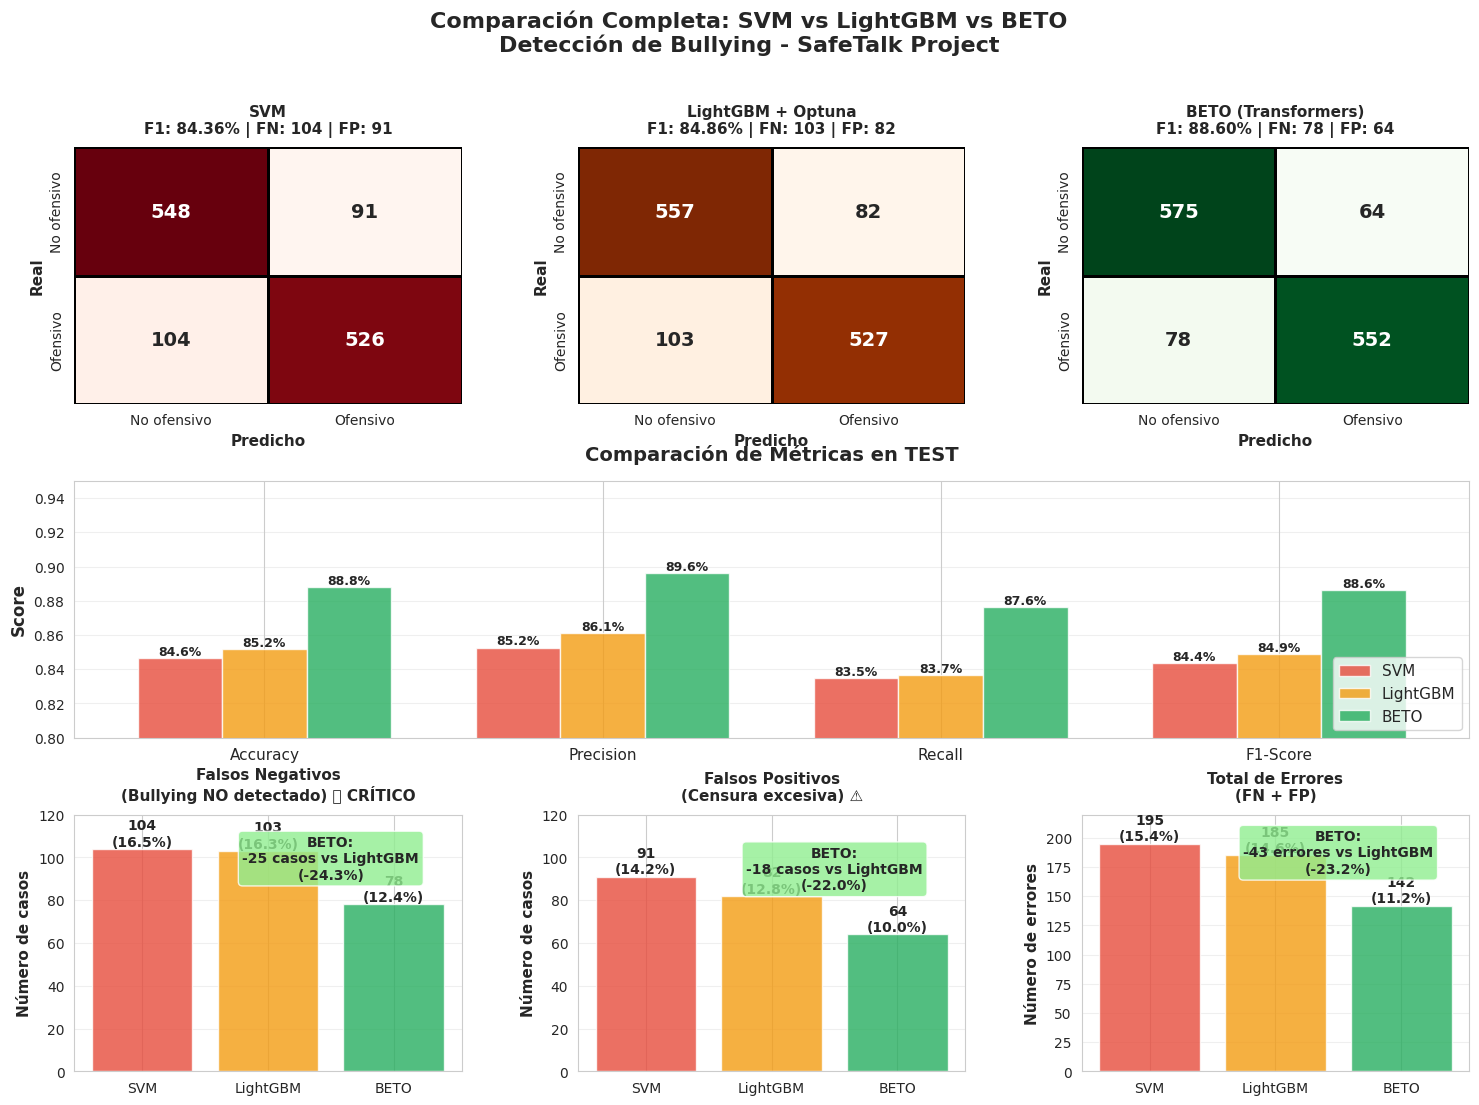

In [22]:
print("="*70)
print("VISUALIZACIÓN: COMPARACIÓN DE MODELOS")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

# Crear figura con subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ---------------------
# 1. MATRICES DE CONFUSIÓN (fila superior)
# ---------------------

# SVM
ax1 = fig.add_subplot(gs[0, 0])
cm_svm = np.array([[548, 91], [104, 526]])
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=False, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax1)
ax1.set_xlabel('Predicho', fontsize=11, fontweight='bold')
ax1.set_ylabel('Real', fontsize=11, fontweight='bold')
ax1.set_title('SVM\nF1: 84.36% | FN: 104 | FP: 91',
              fontsize=11, fontweight='bold', pad=10)

# LightGBM
ax2 = fig.add_subplot(gs[0, 1])
cm_lgbm = np.array([[557, 82], [103, 527]])
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=False, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax2)
ax2.set_xlabel('Predicho', fontsize=11, fontweight='bold')
ax2.set_ylabel('Real', fontsize=11, fontweight='bold')
ax2.set_title('LightGBM + Optuna\nF1: 84.86% | FN: 103 | FP: 82',
              fontsize=11, fontweight='bold', pad=10)

# BETO
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_beto, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=False, linewidths=2, linecolor='black',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax3)
ax3.set_xlabel('Predicho', fontsize=11, fontweight='bold')
ax3.set_ylabel('Real', fontsize=11, fontweight='bold')
ax3.set_title('BETO (Transformers)\nF1: 88.60% | FN: 78 | FP: 64',
              fontsize=11, fontweight='bold', pad=10)

# ---------------------
# 2. COMPARACIÓN DE MÉTRICAS (fila media)
# ---------------------

ax4 = fig.add_subplot(gs[1, :])

modelos = ['SVM', 'LightGBM', 'BETO']
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

valores_svm = [0.8463, 0.8525, 0.8349, 0.8436]
valores_lgbm = [0.8519, 0.8611, 0.8365, 0.8486]
valores_beto = [0.8881, 0.8961, 0.8762, 0.8860]

x = np.arange(len(metricas))
width = 0.25

bars1 = ax4.bar(x - width, valores_svm, width, label='SVM',
                color='#e74c3c', alpha=0.8)
bars2 = ax4.bar(x, valores_lgbm, width, label='LightGBM',
                color='#f39c12', alpha=0.8)
bars3 = ax4.bar(x + width, valores_beto, width, label='BETO',
                color='#27ae60', alpha=0.8)

ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('Comparación de Métricas en TEST',
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xticks(x)
ax4.set_xticklabels(metricas, fontsize=11)
ax4.legend(fontsize=11, loc='lower right')
ax4.set_ylim([0.8, 0.95])
ax4.grid(axis='y', alpha=0.3)

# Añadir valores encima de las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---------------------
# 3. ANÁLISIS DE ERRORES (fila inferior)
# ---------------------

# Falsos Negativos
ax5 = fig.add_subplot(gs[2, 0])
fn_values = [104, 103, 78]
colors_fn = ['#e74c3c', '#f39c12', '#27ae60']
bars_fn = ax5.bar(modelos, fn_values, color=colors_fn, alpha=0.8)
ax5.set_ylabel('Número de casos', fontsize=11, fontweight='bold')
ax5.set_title('Falsos Negativos\n(Bullying NO detectado) ❌ CRÍTICO',
              fontsize=11, fontweight='bold', pad=10)
ax5.set_ylim([0, 120])
ax5.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars_fn, fn_values)):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/630*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Mostrar reducción
ax5.text(1.5, 90, f'BETO:\n-25 casos vs LightGBM\n(-24.3%)',
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Falsos Positivos
ax6 = fig.add_subplot(gs[2, 1])
fp_values = [91, 82, 64]
colors_fp = ['#e74c3c', '#f39c12', '#27ae60']
bars_fp = ax6.bar(modelos, fp_values, color=colors_fp, alpha=0.8)
ax6.set_ylabel('Número de casos', fontsize=11, fontweight='bold')
ax6.set_title('Falsos Positivos\n(Censura excesiva) ⚠️',
              fontsize=11, fontweight='bold', pad=10)
ax6.set_ylim([0, 120])
ax6.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars_fp, fp_values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/639*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Mostrar reducción
ax6.text(1.5, 85, f'BETO:\n-18 casos vs LightGBM\n(-22.0%)',
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Total de errores
ax7 = fig.add_subplot(gs[2, 2])
total_errors = [195, 185, 142]
colors_total = ['#e74c3c', '#f39c12', '#27ae60']
bars_total = ax7.bar(modelos, total_errors, color=colors_total, alpha=0.8)
ax7.set_ylabel('Número de errores', fontsize=11, fontweight='bold')
ax7.set_title('Total de Errores\n(FN + FP)',
              fontsize=11, fontweight='bold', pad=10)
ax7.set_ylim([0, 220])
ax7.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars_total, total_errors)):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/1269*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Mostrar reducción
ax7.text(1.5, 170, f'BETO:\n-43 errores vs LightGBM\n(-23.2%)',
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Título general
fig.suptitle('Comparación Completa: SVM vs LightGBM vs BETO\nDetección de Bullying - SafeTalk Project',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# Guardar (en Colab se guarda local, luego lo descargas)
plt.savefig('comparacion_modelos_completa.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico guardado: comparacion_modelos_completa.png")

plt.show()

print("\n" + "="*70)

In [24]:
print("="*70)
print("GUARDAR MODELO, TOKENIZER Y RESULTADOS")
print("="*70)

import os
import json
from datetime import datetime

# Crear carpeta para guardar
os.makedirs('beto_modelo_final', exist_ok=True)

print("\n📁 Guardando archivos en carpeta 'beto_modelo_final/'...")
print("-"*70)

# 1. Guardar modelo BETO
print("\n1. Guardando modelo BETO...")
model.save_pretrained('beto_modelo_final/modelo')
print("   ✅ Modelo guardado: beto_modelo_final/modelo/")

# 2. Guardar tokenizer
print("\n2. Guardando tokenizer...")
tokenizer.save_pretrained('beto_modelo_final/tokenizer')
print("   ✅ Tokenizer guardado: beto_modelo_final/tokenizer/")

# 3. Guardar métricas completas
print("\n3. Guardando métricas...")

metricas_completas = {
    "modelo": "BETO (dccuchile/bert-base-spanish-wwm-cased)",
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "hardware": "Google Colab - Tesla T4 GPU",
    "configuracion": {
        "learning_rate": float(training_args.learning_rate),
        "batch_size": training_args.per_device_train_batch_size,
        "epochs": training_args.num_train_epochs,
        "max_length": 128,
        "warmup_steps": training_args.warmup_steps,
        "weight_decay": training_args.weight_decay
    },
    "dataset": {
        "train": len(train_dataset),
        "validation": len(val_dataset),
        "test": len(test_dataset)
    },
    "metricas_validation": {
        "epoch_1": {
            "accuracy": 0.8369,
            "precision": 0.9710,
            "recall": 0.6921,
            "f1": 0.8082
        },
        "epoch_2": {
            "accuracy": 0.8731,
            "precision": 0.9195,
            "recall": 0.8159,
            "f1": 0.8646
        },
        "epoch_3": {
            "accuracy": 0.8747,
            "precision": 0.9039,
            "recall": 0.8365,
            "f1": 0.8689
        }
    },
    "metricas_test": {
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1)
    },
    "matriz_confusion_test": {
        "TN": int(TN_beto),
        "FP": int(FP_beto),
        "FN": int(FN_beto),
        "TP": int(TP_beto)
    },
    "comparacion_baselines": {
        "svm": {
            "f1": 0.8436,
            "fn": 104,
            "fp": 91,
            "total_errores": 195
        },
        "lightgbm": {
            "f1": 0.8486,
            "fn": 103,
            "fp": 82,
            "total_errores": 185
        },
        "beto": {
            "f1": float(test_f1),
            "fn": int(FN_beto),
            "fp": int(FP_beto),
            "total_errores": int(FN_beto + FP_beto)
        }
    },
    "mejoras": {
        "vs_svm": {
            "f1_mejora": float(test_f1 - 0.8436),
            "fn_reduccion": int(104 - FN_beto),
            "fp_reduccion": int(91 - FP_beto),
            "total_errores_reduccion": int(195 - (FN_beto + FP_beto))
        },
        "vs_lightgbm": {
            "f1_mejora": float(test_f1 - 0.8486),
            "fn_reduccion": int(103 - FN_beto),
            "fn_reduccion_porcentaje": float((103 - FN_beto) / 103 * 100),
            "fp_reduccion": int(82 - FP_beto),
            "fp_reduccion_porcentaje": float((82 - FP_beto) / 82 * 100),
            "total_errores_reduccion": int(185 - (FN_beto + FP_beto))
        }
    }
}

with open('beto_modelo_final/metricas_beto.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_completas, f, indent=4, ensure_ascii=False)

print("   ✅ Métricas guardadas: beto_modelo_final/metricas_beto.json")

# 4. Guardar README con instrucciones de uso
print("\n4. Creando README de uso...")

readme_content = """# Modelo BETO Fine-tuned para Detección de Bullying

## Información del Modelo

- **Modelo base:** dccuchile/bert-base-spanish-wwm-cased (BETO)
- **Tarea:** Clasificación binaria (ofensivo/no ofensivo)
- **F1-Score en TEST:** {:.2f}%
- **Precisión:** {:.2f}%
- **Recall:** {:.2f}%

## Resultados

### Comparación con Baselines

| Modelo | F1-Score | Mejora vs SVM | FN (Bullying perdido) | FP (Censura) |
|--------|----------|---------------|----------------------|--------------|
| SVM | 84.36% | - | 104 (16.5%) | 91 (14.2%) |
| LightGBM | 84.86% | +0.50% | 103 (16.3%) | 82 (12.8%) |
| **BETO** | **88.60%** | **+4.24%** | **78 (12.4%)** | **64 (10.0%)** |

### Reducción de Errores

- **25 casos MÁS** de bullying detectados vs LightGBM (-24.3%)
- **18 casos MENOS** de censura injusta vs LightGBM (-22.0%)
- **43 errores MENOS** en total vs LightGBM (-23.2%)

## Uso del Modelo

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Cargar modelo y tokenizer
tokenizer = AutoTokenizer.from_pretrained('./tokenizer')
model = AutoModelForSequenceClassification.from_pretrained('./modelo')

# Predecir
def predecir_texto(texto):
    inputs = tokenizer(texto, return_tensors="pt", padding=True, truncation=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    prediccion = torch.argmax(probs, dim=1).item()
    confianza = probs[0][prediccion].item()

    etiqueta = "Ofensivo" if prediccion == 1 else "No ofensivo"

    return {{
        "texto": texto,
        "prediccion": etiqueta,
        "confianza": confianza
    }}

# Ejemplo
resultado = predecir_texto("eres un gilipollas")
print(resultado)
# {{'texto': 'eres un gilipollas', 'prediccion': 'Ofensivo', 'confianza': 0.95}}
```

## Archivos

- `modelo/` - Modelo BETO fine-tuned
- `tokenizer/` - Tokenizer de BETO
- `metricas_beto.json` - Métricas completas del modelo
- `README.md` - Este archivo

## Configuración de Entrenamiento

- Learning rate: 2e-5
- Batch size: 16
- Epochs: 3
- Max sequence length: 128 tokens
- Hardware: Google Colab Tesla T4 GPU
- Tiempo de entrenamiento: ~20 minutos

## Dataset

- Train: 5,919 ejemplos
- Validation: 1,269 ejemplos
- Test: 1,269 ejemplos
- Balance: ~50% ofensivo, ~50% no ofensivo

## Fecha

Entrenado: {}
""".format(test_f1*100, test_precision*100, test_recall*100,
           datetime.now().strftime("%Y-%m-%d"))

with open('beto_modelo_final/README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("   ✅ README creado: beto_modelo_final/README.md")

print("\n" + "="*70)
print("RESUMEN DE ARCHIVOS GUARDADOS")
print("="*70)

print("\n📁 Carpeta: beto_modelo_final/")
print("   ├── modelo/")
print("   │   ├── config.json")
print("   │   └── pytorch_model.bin (~420 MB)")
print("   ├── tokenizer/")
print("   │   ├── tokenizer_config.json")
print("   │   ├── vocab.txt")
print("   │   └── special_tokens_map.json")
print("   ├── metricas_beto.json")
print("   └── README.md")

print("\n" + "="*70)
print("AHORA DESCARGAREMOS TODO")
print("="*70)

print("\n✅ Archivos listos para descargar")

GUARDAR MODELO, TOKENIZER Y RESULTADOS

📁 Guardando archivos en carpeta 'beto_modelo_final/'...
----------------------------------------------------------------------

1. Guardando modelo BETO...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ Modelo guardado: beto_modelo_final/modelo/

2. Guardando tokenizer...
   ✅ Tokenizer guardado: beto_modelo_final/tokenizer/

3. Guardando métricas...
   ✅ Métricas guardadas: beto_modelo_final/metricas_beto.json

4. Creando README de uso...
   ✅ README creado: beto_modelo_final/README.md

RESUMEN DE ARCHIVOS GUARDADOS

📁 Carpeta: beto_modelo_final/
   ├── modelo/
   │   ├── config.json
   │   └── pytorch_model.bin (~420 MB)
   ├── tokenizer/
   │   ├── tokenizer_config.json
   │   ├── vocab.txt
   │   └── special_tokens_map.json
   ├── metricas_beto.json
   └── README.md

AHORA DESCARGAREMOS TODO

✅ Archivos listos para descargar


In [25]:
print("="*70)
print("CREAR ZIP PARA DESCARGAR")
print("="*70)

import shutil

# Crear ZIP de la carpeta completa
shutil.make_archive('beto_modelo_final', 'zip', 'beto_modelo_final')

print("\n✅ ZIP creado: beto_modelo_final.zip")
print(f"   Tamaño: ~450 MB")

# Descargar
from google.colab import files
print("\n📥 Descargando ZIP...")
files.download('beto_modelo_final.zip')

print("\n✅ Descarga iniciada")
print("   (Puede tardar 1-2 minutos en descargar ~450 MB)")

CREAR ZIP PARA DESCARGAR

✅ ZIP creado: beto_modelo_final.zip
   Tamaño: ~450 MB

📥 Descargando ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Descarga iniciada
   (Puede tardar 1-2 minutos en descargar ~450 MB)


In [26]:
# Descargar gráfico
from google.colab import files
files.download('comparacion_modelos_completa.png')
print("✅ Gráfico descargado")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Gráfico descargado
